In [1]:
file_read = "001_fit"
file_write = "003_coefs"

In [2]:
import polars as pl

df_coefs = pl.read_parquet(f"{file_read}_coefs.parquet")

In [3]:
n_features_min = 21

In [4]:
df_coefs_ = df_coefs.filter(pl.col("n_features") == n_features_min)

In [5]:
df_coefs_

pyridone_test,n_features,n_components,2_zero,3_zero,4_zero,6_zero,7_zero,9_zero,12_zero,14_zero,16_zero,18_zero,19_zero,21_zero,46_zero,68_zero,91_zero,148_zero,157_zero,161_zero,232_zero,234_zero,235_zero,237_zero,240_zero,247_zero,252_zero,255_zero,270_zero,271_zero,275_zero,293_zero,324_zero,327_zero,355_zero,357_zero,415_zero,442_zero,465_zero,469_zero,494_zero,505_zero,506_zero,507_zero,519_zero,538_zero,540_zero,543_zero,575_zero,597_zero,602_zero,605_zero,642_zero
i32,i32,i32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0,21,12,null,-0.348087,null,null,0.837663,-0.10886,null,null,null,null,null,null,null,null,-0.390658,null,-0.655436,null,-0.302906,0.217307,0.414054,null,-0.406946,null,null,0.261053,null,0.636914,0.230607,0.156237,-0.807805,-0.112772,null,null,null,null,0.417878,-0.403795,0.260154,null,-0.371035,null,null,null,-0.053093,0.391835,null,null,null,null,null
1,21,8,-0.077306,null,null,0.213921,0.185891,-0.348637,null,null,null,null,null,null,null,null,-0.183508,-0.09944,-0.371014,null,-0.115311,0.242013,0.159497,null,null,null,null,null,null,0.261631,null,null,-0.305862,-0.264134,null,null,-0.149292,null,null,-0.165871,0.26836,null,-0.306669,0.035255,null,null,null,0.390315,null,-0.154486,-0.101558,null,null
2,21,9,-0.083721,null,null,-0.028821,0.272078,-0.256248,0.058441,null,null,null,null,null,null,null,-0.245893,null,-0.393652,null,-0.294233,0.34356,0.288521,null,-0.162862,null,null,null,null,0.394896,null,null,-0.259212,-0.13383,null,null,null,null,-0.03522,-0.241044,0.215708,null,-0.308174,0.058512,null,null,null,0.579742,null,-0.235737,null,null,null
3,21,7,-0.144108,null,null,null,0.264882,-0.341581,0.213,null,null,null,null,null,null,null,-0.148513,-0.140138,-0.217808,null,-0.312304,0.326027,null,null,-0.086866,null,null,null,null,0.221333,null,null,-0.094286,-0.223569,null,null,-0.076892,null,-0.128785,-0.168327,0.207858,null,-0.214156,0.107973,null,null,null,0.208228,null,-0.107225,null,null,null
4,21,8,-0.09542,null,null,null,0.274729,-0.258618,0.181181,null,null,0.085246,null,null,null,null,-0.263469,null,-0.28143,null,-0.35228,0.261763,0.099005,null,-0.123788,null,null,null,null,0.256196,null,null,-0.156779,-0.177827,null,null,null,null,-0.157495,-0.173177,0.233961,null,-0.293156,null,null,null,0.091089,0.559856,null,-0.22187,null,null,null
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
8,21,9,-0.146157,null,-0.084543,null,0.374187,-0.275564,0.063521,null,null,null,null,null,null,0.117525,null,null,-0.316176,null,-0.250626,0.349186,null,null,-0.272079,null,null,null,0.046279,0.198953,null,null,-0.178516,-0.158119,null,0.074227,-0.039137,null,null,null,0.135278,null,-0.371754,null,null,null,-0.131095,0.533209,null,-0.226431,null,null,null
9,21,4,-0.046459,null,null,null,0.133899,-0.17276,null,null,0.097438,null,0.115108,null,null,0.103672,null,-0.08051,-0.173493,null,-0.231873,0.162555,null,null,-0.097399,null,null,null,-0.107097,null,null,null,-0.124847,0.033926,-0.107133,null,null,null,-0.114553,null,null,null,-0.167439,0.113051,null,null,0.145773,0.172831,null,-0.214293,null,null,null
10,21,9,null,-0.109242,null,null,0.422794,-0.229983,null,null,null,null,null,null,null,null,-0.27046,null,-0.435896,null,-0.236589,0.254586,0.343146,null,-0.269354,null,null,0.158864,null,0.350854,0.044846,null,-0.388455,-0.107482,null,null,null,null,null,-0.257425,0.207421,null,-0.407892,0.077619,0.166908,null,null,0.544962,null,-0.113127,null,null,null


In [6]:
columns_feat = [column for column in df_coefs_.columns if "zero" in column]

In [7]:
data = df_coefs_[columns_feat].to_numpy()

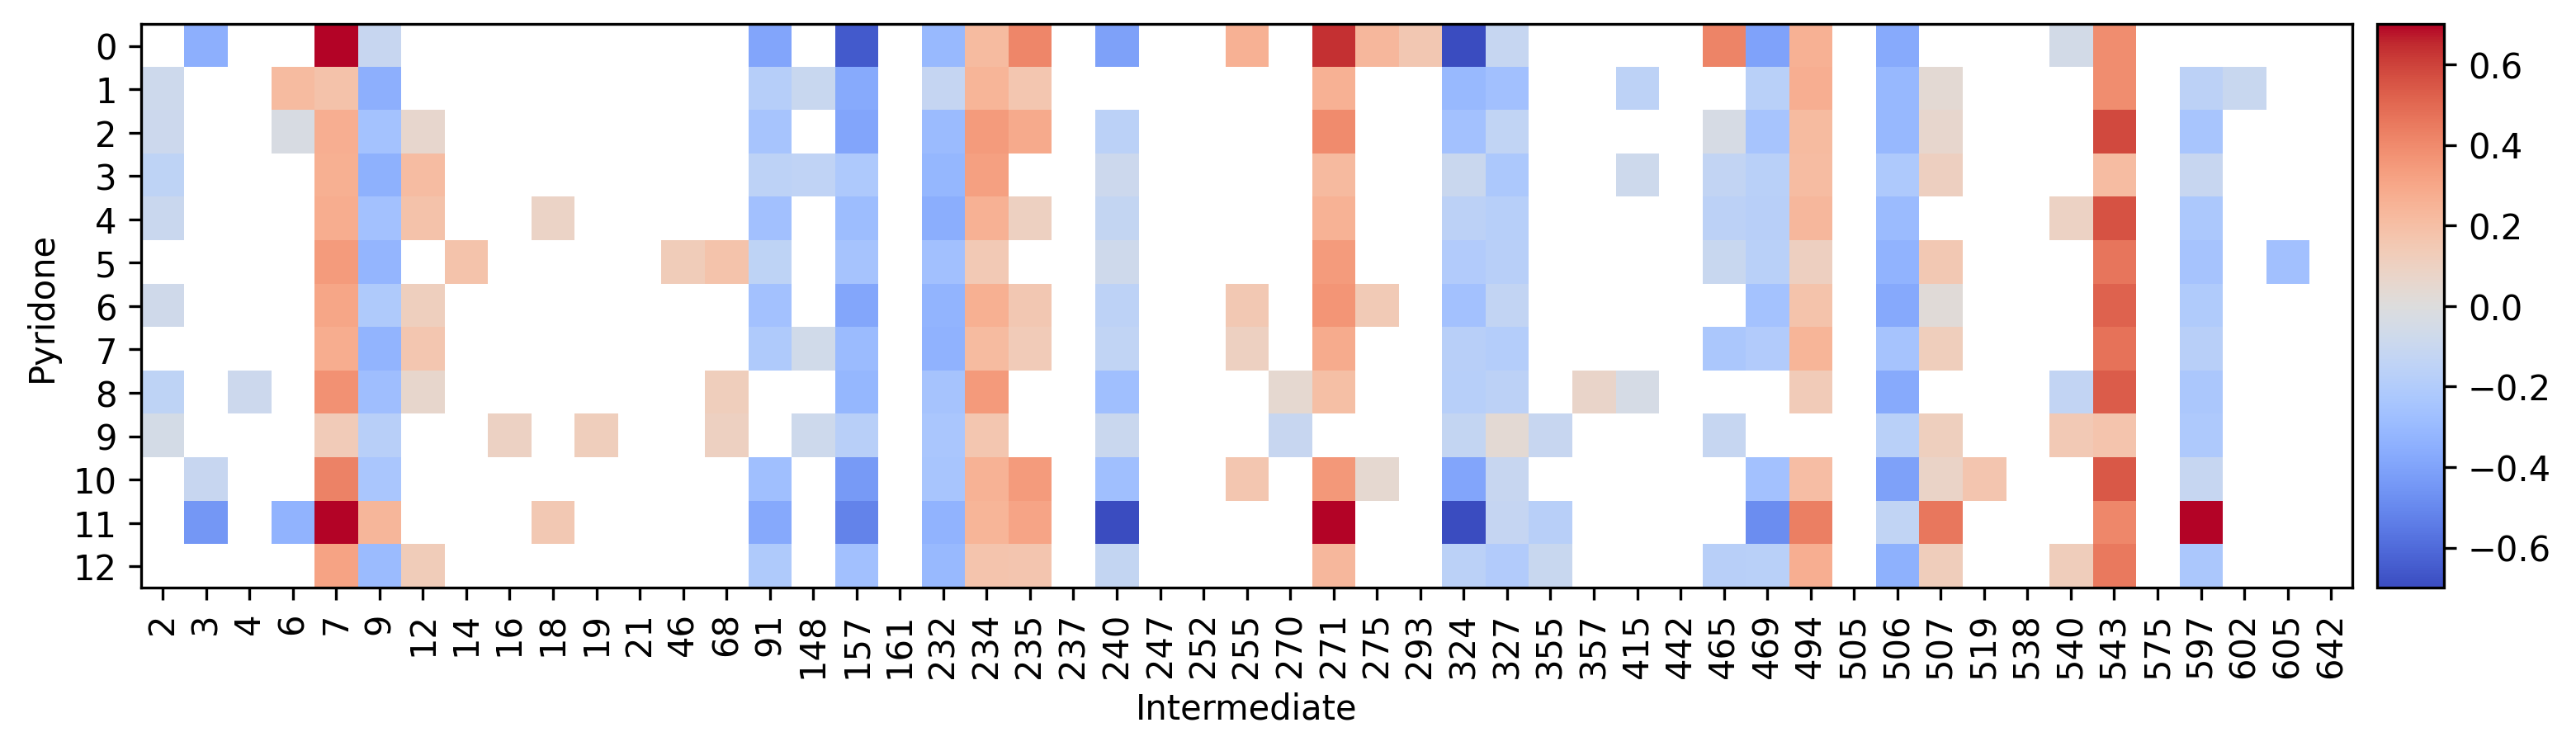

In [8]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.axes_grid1 import make_axes_locatable

fig, ax = plt.subplots(figsize=(12, 4), dpi=300)

im = ax.imshow(data, vmin=-0.7, vmax=0.7, cmap="coolwarm")

ax.set_xlabel("Intermediate")
ax.set_ylabel("Pyridone")
ax.set_xticks(np.arange(data.shape[1]))
ax.set_yticks(np.arange(data.shape[0]))
ax.set_xticklabels([c[:-5] for c in columns_feat], rotation=90)
ax.set_yticklabels(df_coefs_["pyridone_test"])

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="3%", pad=0.1)
fig.colorbar(im, cax=cax)

plt.savefig(
    f"{file_write}_imshow.png",
    transparent=True,
    bbox_inches="tight",
    pad_inches=0.1
)
plt.show()

In [9]:
data_mean = df_coefs_[columns_feat].fill_null(0.0).mean().to_numpy().ravel()
data_std = df_coefs_[columns_feat].fill_null(0.0).std(ddof=1).to_numpy().ravel()
data_std = np.where(data_std == 0.0, np.nan, data_std)

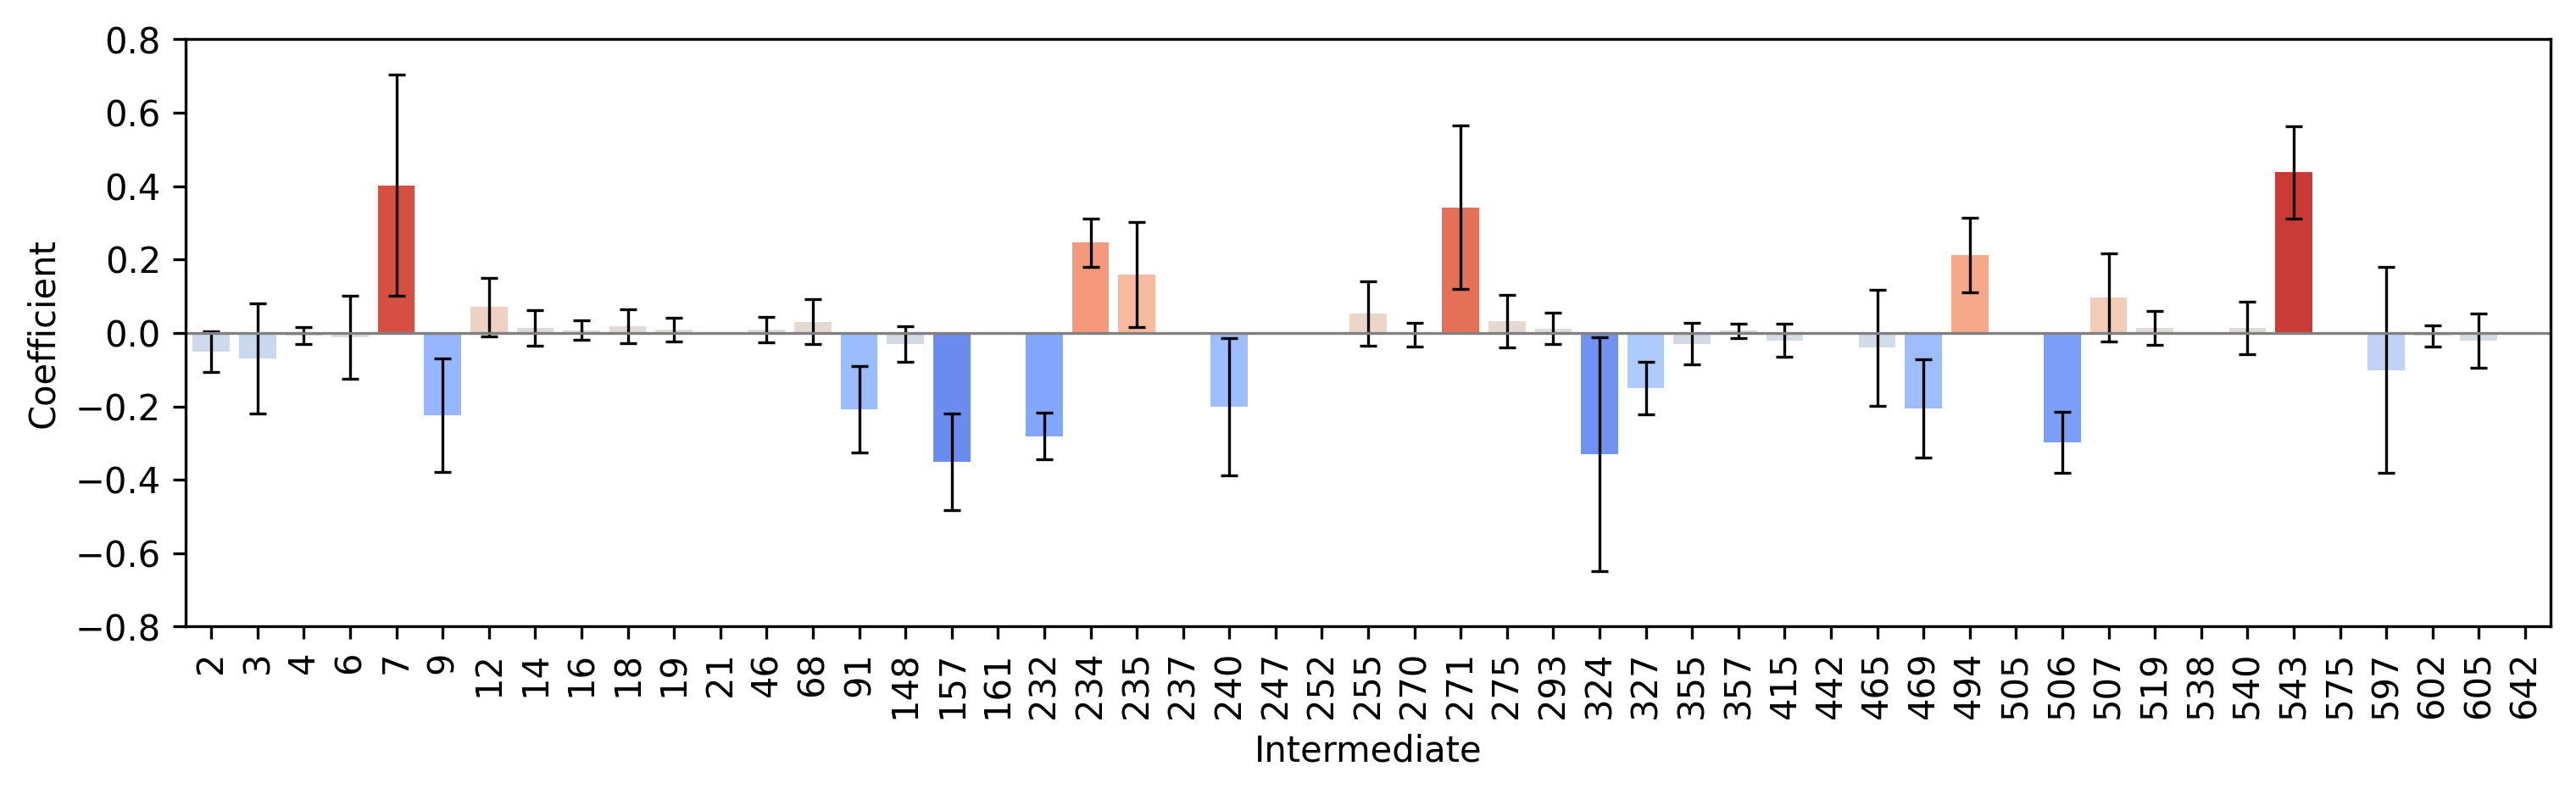

In [10]:
import matplotlib.colors as mcolors

fig, ax = plt.subplots(figsize=(12, 3), dpi=300)

norm = mcolors.TwoSlopeNorm(vcenter=0.0, vmin=-0.5, vmax=0.5)
colors = plt.cm.coolwarm(norm(data_mean))
error_kw = dict(elinewidth=0.8, capthick=0.8)
ax.bar(
    np.arange(len(data_mean)),
    data_mean,
    yerr=data_std,
    color=colors,
    capsize=2.5,
    error_kw=error_kw
)
ax.axhline(0, color="gray", linewidth=0.8)

ax.set_xlabel("Intermediate")
ax.set_ylabel("Coefficient")
ax.set_xticks(np.arange(len(data_mean)))
ax.set_xticklabels([c[:-5] for c in columns_feat], rotation=90)
ax.margins(x=0.003)
ax.set_ylim(-0.8, 0.8)

plt.savefig(
    f"{file_write}_bar.png",
    transparent=True,
    bbox_inches="tight",
    pad_inches=0.1
)
plt.show()